# 第3章：Coding Attention Mechanisms

**目标：** 从零实现注意力机制——Transformer 的核心组件

```
简单权重注意力 → 可学习的自注意力(Q/K/V) → 因果掩码 → Multi-Head Attention
```

**前置回顾（第2章）：**
- 文本经过 Tokenization → Token Embedding + Positional Embedding → 输入向量
- 每个 token 得到一个 `d_model` 维的向量
- 现在的问题：每个 token 只知道自己，不知道上下文 → 注意力机制解决这个问题！

---

## 3.1 注意力机制的直觉理解

**核心问题：** 同一个词在不同语境中含义不同，如何让模型「根据上下文理解语义」？

**例子：**
- "The **bank** of the river was steep." → bank = 河岸
- "I went to the **bank** to withdraw money." → bank = 银行

**注意力的核心思想：**
- 对于每个 token，计算它与序列中**所有其他 token** 的相关性（注意力权重）
- 用这些权重对所有 token 的表示做加权平均，得到一个融合了上下文信息的新表示

```
输入:  [x₁, x₂, x₃, ..., xₙ]   每个 xᵢ 是独立的嵌入向量
                ↓ 注意力机制
输出:  [z₁, z₂, z₃, ..., zₙ]   每个 zᵢ 融合了全序列的上下文信息
```

> 💡 **关键洞察：** 注意力机制本质是一种**加权平均**——让模型自己学习「在当前位置应该关注哪些 token」。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

torch.manual_seed(42)

# 准备一个简单的输入序列（6个token，每个token用3维向量表示）
inputs = torch.tensor(
    [[0.43, 0.15, 0.89],  # Your     (x₁)
     [0.55, 0.87, 0.66],  # journey  (x₂)
     [0.57, 0.85, 0.64],  # starts   (x₃)
     [0.22, 0.58, 0.33],  # with     (x₄)
     [0.77, 0.25, 0.10],  # one      (x₅)
     [0.05, 0.80, 0.55]]  # step     (x₆)
)

print(f"输入序列 shape: {inputs.shape}")  # (6, 3)
print(f"→ {inputs.shape[0]} 个 token，每个 {inputs.shape[1]} 维")

输入序列 shape: torch.Size([6, 3])
→ 6 个 token，每个 3 维


---
## 3.2 简化的自注意力（无可学习参数）

我们先实现最简单的版本：用**点积**计算 token 之间的相似度，然后做加权平均。

**步骤：**
1. 计算 query token 与所有 token 的点积（相似度分数）
2. 用 softmax 归一化为概率（注意力权重）
3. 用权重对所有 token 做加权平均 → 得到上下文向量

In [2]:
# Step 1: 以 x₂ ("journey") 为例，计算它和所有 token 的点积
query = inputs[1]  # x₂

attn_scores = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores[i] = torch.dot(query, x_i)

# 点积在几何上代表两个向量其模的乘积再乘以其夹角的余弦值， 如果是同一个两个同样的向量的点积，那么就是模的平方
print(f"注意力分数 (原始点积): {attn_scores}")
print(f"→ x₂ 与自己的点积最大: {attn_scores[1]:.4f}")
print(f"→ x₂ 与 x₃ 的点积也很大: {attn_scores[2]:.4f} (因为向量很相似)")

注意力分数 (原始点积): tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
→ x₂ 与自己的点积最大: 1.4950
→ x₂ 与 x₃ 的点积也很大: 1.4754 (因为向量很相似)


> 💡 **关于点积的三种计算方式：**
>
> | 方式 | 公式 | 适用场景 |
> |------|------|---------|
> | 几何 | $\|\mathbf{a}\| \cdot \|\mathbf{b}\| \cdot \cos\theta$ | 理解直觉含义 |
> | 代数 | $\sum a_i b_i$（逐元素相乘再求和） | 手算单对向量 |
> | 矩阵 | $\mathbf{a}^T \mathbf{b}$ 或批量 $X \cdot X^T$ | 批量计算，GPU 加速 |
>
> 三种写法结果完全一样。矩阵形式的优势是**一次性算所有向量对的点积**，
> 例如 `inputs @ inputs.T` 就是一个 (6,3) × (3,6) → (6,6) 的矩阵乘法，一步得到 36 个点积值。
> 这就是深度学习中到处使用矩阵乘法的原因。

> 💡 **关于点积与相似度的洞察：**
>
> 点积同时受**方向**和**模长**两个因素影响，所以它不是纯粹的方向相似度度量。
> 纯粹衡量方向相似度应该用**余弦相似度**（点积 ÷ 两个模长之积）。
>
> 但注意力机制**故意**选用点积而非余弦相似度——因为 Q/K 向量是通过可学习的权重矩阵 $W_Q$、$W_K$ 生成的，
> 模型可以通过训练自主控制向量的模长，让模长也承载"这个 token 有多值得关注"的信息。
> 因此点积比余弦相似度**更灵活**：既编码方向相似性，也编码重要性。
>
> ⚠️ **注意：** 上述洞察在本节（3.2 简化版）中并不真正体现，因为这里的 `inputs` 是手动给定的固定数值，
> 没有可学习参数，点积受模长干扰的问题被回避了。本节的目的纯粹是教学演示"计算相似度 → 归一化 → 加权平均"的流程。
> 这个洞察真正发挥作用是在 **3.3 节**引入 $W_Q, W_K, W_V$ 之后——模型才有能力通过学习来控制模长，让点积中的模长贡献变成有意义的信号。

In [3]:
# Step 2: softmax 归一化
attn_weights = F.softmax(attn_scores, dim=0)

print(f"注意力权重 (softmax后): {attn_weights}")
print(f"权重之和: {attn_weights.sum():.4f}")  # 应该 = 1.0
print(f"\n→ x₂ 最关注自己 ({attn_weights[1]:.4f}) 和 x₃ ({attn_weights[2]:.4f})")

注意力权重 (softmax后): tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
权重之和: 1.0000

→ x₂ 最关注自己 (0.2379) 和 x₃ (0.2333)


In [4]:
# Step 3: 加权平均 → 上下文向量
context_vec = torch.zeros(query.shape)
print(query.shape)
for i, x_i in enumerate(inputs):
    context_vec += attn_weights[i] * x_i

print(f"x₂ 的上下文向量: {context_vec}")
print(f"原始 x₂:         {query}")
print(f"\n→ 上下文向量融合了其他 token 的信息，与原始 x₂ 不同")

torch.Size([3])
x₂ 的上下文向量: tensor([0.4419, 0.6515, 0.5683])
原始 x₂:         tensor([0.5500, 0.8700, 0.6600])

→ 上下文向量融合了其他 token 的信息，与原始 x₂ 不同


In [5]:
# 向量化：一次性计算所有 token 的注意力（矩阵乘法）
# attn_scores[i][j] = dot(inputs[i], inputs[j])
# @ 是矩阵乘法，(6, 3) @ (3, 6) → (6, 6)：
attn_scores_all = inputs @ inputs.T
print(f"注意力分数矩阵 shape: {attn_scores_all.shape}")
print(f"\n注意力分数矩阵:\n{attn_scores_all}")

# softmax 对每行归一化
attn_weights_all = F.softmax(attn_scores_all, dim=-1)
print(f"\n注意力权重矩阵:\n{attn_weights_all}")
print(f"\n每行之和: {attn_weights_all.sum(dim=-1)}")

# 一步得到所有上下文向量
all_context_vecs = attn_weights_all @ inputs
print(f"\n所有上下文向量 shape: {all_context_vecs.shape}")
print(f"x₂ 的上下文向量 (矩阵版): {all_context_vecs[1]}")
print(f"x₂ 的上下文向量 (循环版): {context_vec}")
print(f"→ 两者一致！")

注意力分数矩阵 shape: torch.Size([6, 6])

注意力分数矩阵:
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

注意力权重矩阵:
tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

每行之和: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

所有上下文向量 shape: torch.Size([6, 3])
x₂ 的上下文向量 (矩阵版): tensor([0.4419, 0.6515, 0.5683])
x₂ 的上下文向量 (循环版): tensor([0.4419, 0.6515, 0.5683])
→ 两者一致！


### ✏️ 练习
1. 为什么用 softmax 而不是简单的除以总和来归一化？两者有什么区别？<br>
   简单的归一化无法处理负数的情况，softmax 应该是专门为归一化做的封装？已经考虑了各种情况下对归一化处理的最优方案，使用者无需关注实现细节
   
   简单除以总和（x_i / sum(x)）无法处理负数和零总和的情况，归一化后可能出现负权重或除零错误。而 softmax 保证所有输出严格为正且和为 1，形成有效的概率分布。此外，softmax 的指数运算会放大分数之间的差异，让模型更聚焦于高相关性的 token，同时它处处可导，便于梯度反向传播训练。
2. 如果把 `dim=-1` 改成 `dim=0`，softmax 的效果会怎样？这两种归一化方式分别对应什么含义？
   `dim=0`在列的内部进行规划，不符合我们现在的我们的需求
3. 观察注意力权重矩阵，为什么对角线上的值往往最大？
   对角线是向量与自身的点积（模长的平方），在输入向量模长相近的情况下，自身点积往往最大，但这不是数学上的必然。

In [6]:
# 在这里做实验

---
## 3.3 带可学习参数的自注意力 (Q/K/V) ⭐⭐

上面的简化版有一个根本问题：注意力权重完全由输入的相似度决定，**模型无法学习**。

**解决方案：** 引入三个可学习的投影矩阵 $W_q$, $W_k$, $W_v$：

$$
q_i = x_i W_q, \quad k_i = x_i W_k, \quad v_i = x_i W_v
$$

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

**三种向量的直觉：**
- **Query (查询)**: 「我在找什么信息？」
- **Key (键)**: 「我能提供什么信息？」
- **Value (值)**: 「我实际包含的信息是什么？」

> 💡 **为什么除以 $\sqrt{d_k}$？** 防止点积随着维度增大而变得过大，导致 softmax 输出接近 one-hot（梯度消失）。

In [7]:
# 先用手动矩阵实现，理解原理

x_2 = inputs[1]  # 以 x₂ 为例
d_in = inputs.shape[1]   # 输入维度 = 3
d_out = 2                # 输出维度 = 2 (为了演示，Q/K/V 投影到更低维度)

# 三个可学习的权重矩阵
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

# 计算 x₂ 的 query
# @ 是矩阵乘法 again
print(f"x_2: {x_2}  (shape: {x_2.shape})")
print(f"W_query shape: {W_query.shape}")
# PyTorch 的规则是： 一维向量 @ 二维矩阵时，自动把向量当作行向量（1×n），乘完后再去掉添加的那个维度，结果还是一维。
query_2 = x_2 @ W_query
print(f"x₂ 的 Query: {query_2}  (shape: {query_2.shape})")

# 计算所有 token 的 key 和 value
keys = inputs @ W_key
values = inputs @ W_value
print(f"Keys shape:   {keys.shape}")   # (6, 2)
print(f"Values shape: {values.shape}")  # (6, 2)

x_2: tensor([0.5500, 0.8700, 0.6600])  (shape: torch.Size([3]))
W_query shape: torch.Size([3, 2])
x₂ 的 Query: tensor([0.4306, 1.4551])  (shape: torch.Size([2]))
Keys shape:   torch.Size([6, 2])
Values shape: torch.Size([6, 2])


In [8]:
# 计算 x₂ 对所有 token 的注意力分数
attn_scores_2 = query_2 @ keys.T  # (2,) @ (2, 6) → (6,)
print(f"注意力分数: {attn_scores_2}")

# Scaled dot-product: 除以 sqrt(d_k)
d_k = keys.shape[-1]
# 这里写 dim=-1 而不是 dim=0，原因和之前 shape[-1] 一样——习惯性写法，为了通用性。后面实际模型中注意力分数会是多维的，比如 [batch, seq_len, seq_len]，dim=-1 始终能正确地对最后一维做 softmax，不用根据维度数去改代码。
attn_weights_2 = F.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(f"注意力权重 (scaled): {attn_weights_2}")

# 加权平均得到上下文向量
context_vec_2 = attn_weights_2 @ values
print(f"\nx₂ 的上下文向量: {context_vec_2}")
print(f"→ 维度从 {d_in} 变为 {d_out}，因为 V 的投影维度是 {d_out}")

注意力分数: tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])
注意力权重 (scaled): tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])

x₂ 的上下文向量: tensor([0.3061, 0.8210])
→ 维度从 3 变为 2，因为 V 的投影维度是 2


In [9]:
# 封装为 nn.Module
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        queries = x @ self.W_query
        keys    = x @ self.W_key
        values  = x @ self.W_value

        attn_scores = queries @ keys.T
        attn_weights = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vecs = attn_weights @ values
        return context_vecs


torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in=3, d_out=2)
output = sa_v1(inputs)
print(f"自注意力输出 shape: {output.shape}")
print(f"输出:\n{output}")

自注意力输出 shape: torch.Size([6, 2])
输出:
tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [10]:
# 改进版：使用 nn.Linear 代替手动 Parameter（更规范，支持 bias 选项）
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        context_vecs = attn_weights @ values
        return context_vecs


torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in=3, d_out=2)
output_v2 = sa_v2(inputs)
print(f"SelfAttention_v2 输出:\n{output_v2}")

SelfAttention_v2 输出:
tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


### 🤔 思考：`nn.Parameter` vs `nn.Linear`

| 方式 | 本质 | 区别 |
|------|------|------|
| `nn.Parameter(torch.rand(d_in, d_out))` | 手动创建可学习矩阵 | `x @ W`，转置是手动的 |
| `nn.Linear(d_in, d_out, bias=False)` | 自动管理的线性层 | 内部做 `x @ W.T + bias`，权重初始化更合理 |

在实际实现中，推荐使用 `nn.Linear`，因为它有更好的权重初始化策略。

### ✏️ 练习
1. 在 `SelfAttention_v1` 中，如果去掉 `/ keys.shape[-1]**0.5`（不做 scaling），注意力权重会有什么变化？为什么？

    不除以 √d_k，在 d_k 较大时点积的方差会变成 d_k，导致 softmax 输出非常尖锐（接近 one-hot）、梯度接近 0，训练难以收敛。除以 √d_k 是为了把点积的方差归一化到 1，让注意力权重保持适度的平滑性和健康的梯度。这就是 Transformer 论文里 "Scaled Dot-Product Attention" 名字的由来。

2. `SelfAttention_v2` 用了 `nn.Linear`，它的权重矩阵 shape 和 `v1` 有什么不同？（提示：`nn.Linear` 内部存储的是转置后的矩阵）

    v1 的权重是 (d_in, d_out)，配合 x @ W 使用；v2 用的 nn.Linear 把权重存成 (d_out, d_in)（转置形式），内部计算的是 x @ W.T。两者数学上等价，只是存储约定不同——nn.Linear 的约定更符合"每行一个输出神经元"的硬件友好排布。
    
3. 如果 `d_out > d_in` 会怎样？这在实际中有意义吗？

    d_out > d_in 在技术上完全可行，注意力权重和上下文向量的计算依然成立。从信息论看，单次线性投影不会增加信息量，但升维后的高维空间能让模型更容易学到线性可分的特征表示，因此在实际中是有意义的——Transformer 的 FFN 层和 Multi-Head Attention 的总输出维度都体现了这一点。只是单纯在自注意力的 Q/K/V 投影里把 d_out 设得远大于 d_in，收益会递减，所以一般会配合多头机制来使用。

In [11]:
# 在这里做实验

---
## 3.4 因果注意力 (Causal Attention) ⭐⭐⭐

**问题：** 上面的自注意力是「双向」的——每个 token 能看到全部序列。但 GPT 是自回归模型，预测下一个 token 时**不能看到未来**！

**解决方案：因果掩码（Causal Mask）**
- 把注意力矩阵的**上三角**设为 $-\infty$
- softmax 后这些位置变成 0
- 效果：token $i$ 只能关注 $\leq i$ 位置的 token

```
无掩码:          有掩码:
✓ ✓ ✓ ✓         ✓ ✗ ✗ ✗
✓ ✓ ✓ ✓   →     ✓ ✓ ✗ ✗
✓ ✓ ✓ ✓         ✓ ✓ ✓ ✗
✓ ✓ ✓ ✓         ✓ ✓ ✓ ✓
```

In [12]:
# 演示因果掩码的实现

# Step 1: 计算正常的注意力分数
queries = sa_v2.W_query(inputs)
keys    = sa_v2.W_key(inputs)
values  = sa_v2.W_value(inputs)

attn_scores = queries @ keys.T
print(f"原始注意力分数:\n{attn_scores}")

原始注意力分数:
tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)


In [30]:
# Step 2: 创建因果掩码（上三角为 True）
print(f"inputs.shape: {inputs.shape}")
seq_len = inputs.shape[0]
print(f"seq_len: {seq_len}")
mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
print(f"因果掩码 (True = 被遮挡):\n{mask.int()}")

inputs.shape: torch.Size([6, 3])
seq_len: 6
因果掩码 (True = 被遮挡):
tensor([[0, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0]], dtype=torch.int32)


In [31]:
# Step 3: 将被遮挡的位置设为 -inf
attn_scores_masked = attn_scores.masked_fill(mask, -torch.inf)
print(f"掩码后的注意力分数:\n{attn_scores_masked}")

掩码后的注意力分数:
tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [15]:
# Step 4: softmax → 被遮挡的位置变成 0
attn_weights_masked = F.softmax(attn_scores_masked / keys.shape[-1]**0.5, dim=-1)
print(f"因果注意力权重:\n{attn_weights_masked}")
print(f"\n→ 每行只有前 i+1 个位置有非零权重！")
print(f"→ 第1个 token 只能关注自己")
print(f"→ 最后一个 token 能关注所有 token")

因果注意力权重:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

→ 每行只有前 i+1 个位置有非零权重！
→ 第1个 token 只能关注自己
→ 最后一个 token 能关注所有 token


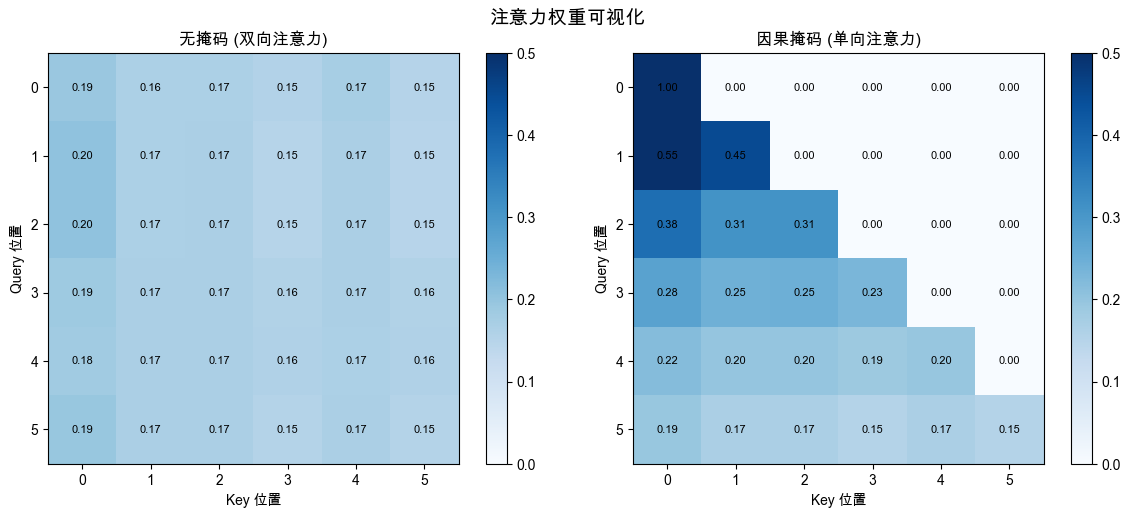

In [16]:
# 可视化：对比有/无因果掩码
attn_weights_no_mask = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(attn_weights_no_mask.detach().numpy(), cmap='Blues', vmin=0, vmax=0.5)
axes[0].set_title('无掩码 (双向注意力)')
axes[0].set_xlabel('Key 位置')
axes[0].set_ylabel('Query 位置')
for i in range(seq_len):
    for j in range(seq_len):
        axes[0].text(j, i, f'{attn_weights_no_mask[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(attn_weights_masked.detach().numpy(), cmap='Blues', vmin=0, vmax=0.5)
axes[1].set_title('因果掩码 (单向注意力)')
axes[1].set_xlabel('Key 位置')
axes[1].set_ylabel('Query 位置')
for i in range(seq_len):
    for j in range(seq_len):
        axes[1].text(j, i, f'{attn_weights_masked[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im2, ax=axes[1])

plt.suptitle('注意力权重可视化', fontsize=14)
plt.tight_layout()
plt.show()

### ✏️ 练习
1. 如果用 `diagonal=0` 而不是 `diagonal=1` 创建 mask，效果会怎样？token 能看到自己吗？

    用 diagonal=0 会把主对角线也屏蔽掉。后果是：

    第一个 token 所在行会全是 -inf，softmax 输出 NaN，训练直接崩
    其它 token 虽然不会 NaN，但都看不到自己，语义上是错的
    所以因果掩码必须用 diagonal=1，让每个 token 至少能看到自己。
2. 为什么用 `-inf` 而不是 `0` 或 `-1` 来做掩码？（提示：想想 softmax 的行为）

    因为 softmax 是 e^x / Σe^x，要让某个位置的权重严格为 0，只能让它的输入趋于 -inf（这样 e^(-inf) = 0）。用 0 或 -1 填充时 e^x 仍是有限值，权重不会归零，达不到"屏蔽"的效果。这其实和上一题"整行 -inf 会变 NaN"是同一个数学特性——既要利用它把屏蔽位置归零，又要避免它把整行归零。
3. 观察因果注意力权重矩阵的第一行，它代表什么含义？

    因果注意力权重矩阵的第一行是 [1, 0, 0, ..., 0]，表示第一个 token 100% 只关注自己，因为它没有任何"过去"可以参考。它的上下文向量 z₀ 等于自己的 value 向量 v₀，完全没有上下文融合——这也反映了自回归模型的根本限制：序列开头的 token 缺乏上下文信息。

In [32]:
# 在这里做实验
scores = torch.zeros(3, 3)
mask0 = torch.triu(torch.ones(3, 3), diagonal=0).bool()
mask1 = torch.triu(torch.ones(3, 3), diagonal=1).bool()
print("diagonal=0:\n", torch.softmax(scores.masked_fill(mask0, -torch.inf), dim=-1))
print("diagonal=1:\n", torch.softmax(scores.masked_fill(mask1, -torch.inf), dim=-1))

diagonal=0:
 tensor([[   nan,    nan,    nan],
        [1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000]])
diagonal=1:
 tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])


---
## 3.5 Dropout 在注意力中的应用

**为什么需要 Dropout？**
- 防止模型过度依赖某些特定的注意力模式
- 增加模型的鲁棒性
- 训练时随机「丢弃」一些注意力连接，推理时使用全部


**Dropout 应用位置：**
1. 注意力权重上（softmax 之后）
2. 最终输出上

#### Dropout更容易理解的解释

Dropout 在注意力机制中随机切断一部分 token 之间的注意力连接，效果上相当于训练时让模型同时学会"使用完整注意力"和"使用残缺注意力"两种情形。这样模型就不会过度依赖某条特定的"token A 必须看 token B"的强连接，而是学会从多个 token 中分散获取信息——这就是"防止过度依赖某些特定注意力模式"的真正含义。最终效果：注意力分布更分散、对训练集中特定模式不过拟合、对新输入的泛化能力更强


#### 一个直观的比喻
把注意力权重矩阵想象成一张社交网络：每个 token 是一个人，权重是他们之间"关注度"。

没有 Dropout：如果 A 和 B 长期是"挚友"（强连接），A 遇到任何问题都只问 B。一旦 B 不在场或有偏见，A 就完蛋。
有 Dropout：每次社交聚会上，A 和 B 都有可能"突然失联"。这逼着 A 学会和 C、D、E 也建立有用联系，整个社交网络变得更稳健——任何一对关系断掉，都不会让某个人陷入信息孤岛。

In [18]:
# Dropout 基础
torch.manual_seed(123)
dropout = nn.Dropout(p=0.5)  # 50% 的概率丢弃

example = torch.ones(6, 6)
print(f"原始矩阵:\n{example}")
print(f"\nDropout 后:\n{dropout(example)}")
print(f"\n→ 注意：未被丢弃的值被放大了 {1/(1-0.5):.0f} 倍，保持期望值不变")

原始矩阵:
tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

Dropout 后:
tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])

→ 注意：未被丢弃的值被放大了 2 倍，保持期望值不变


In [19]:
# 对注意力权重应用 dropout
torch.manual_seed(123)
print(f"因果注意力权重 (原始):\n{attn_weights_masked}")
print(f"\n因果注意力权重 (dropout 后):\n{dropout(attn_weights_masked)}")
print(f"\n→ 某些注意力连接被随机「断开」，迫使模型不要过度依赖特定的 token 关系")

因果注意力权重 (原始):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

因果注意力权重 (dropout 后):
tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)

→ 某些注意力连接被随机「断开」，迫使模型不要过度依赖特定的 token 关系


### ✏️ 练习
1. 为什么 dropout 后，未被丢弃的值会变大？（提示：保持期望值不变）

  为了保持期望不变，需要在丢弃一部分的值之后，将剩下的元素乘以一定的系数来补偿。
  
2. `model.eval()` 时 dropout 会怎样？为什么训练和推理的行为不同？
3. 如果 dropout rate = 0.0，和不使用 dropout 有区别吗？

In [ ]:
# 在这里做实验

---
## 3.6 完整的因果注意力模块

将前面所有的组件组合在一起：Q/K/V 投影 + Scaled Dot-Product + 因果掩码 + Dropout

In [21]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout  = nn.Dropout(dropout)
        # register_buffer: 不是模型参数，但需要随模型保存/加载
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)  # (b, num_tokens, d_out)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # Scaled dot-product attention
        attn_scores = queries @ keys.transpose(1, 2)  # (b, num_tokens, num_tokens)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )
        attn_weights = F.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vecs = attn_weights @ values  # (b, num_tokens, d_out)
        return context_vecs


# 测试
torch.manual_seed(123)
context_length = 6
d_in = 3
d_out = 2

ca = CausalAttention(d_in, d_out, context_length, dropout=0.0)
batch = inputs.unsqueeze(0)  # 加 batch 维度: (1, 6, 3)
output = ca(batch)

print(f"输入 shape: {batch.shape}")
print(f"输出 shape: {output.shape}")
print(f"\n输出:\n{output}")

输入 shape: torch.Size([1, 6, 3])
输出 shape: torch.Size([1, 6, 2])

输出:
tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


### 🤔 思考

**为什么用 `register_buffer` 而不是普通属性？**

- `register_buffer('mask', ...)` 让 mask 跟随模型一起 `.to(device)`
- 当模型被移到 GPU 时，mask 也会自动移过去
- 但它不会被当作模型参数（不参与梯度计算、不被优化器更新）
- 保存/加载模型时会自动包含 buffer

---

## 3.7 多头注意力 (Multi-Head Attention) ⭐⭐⭐

**问题：** 单头注意力只能学习一种「关注模式」。但语言的复杂性需要同时关注多种关系：
- 语法关系（主语-谓语）
- 语义关系（同义词）
- 位置关系（相邻词）

**解决方案：** 用多个注意力头并行处理，每个头学习不同的关注模式。

```
输入 x (d_model=768)
    │
    ├── Head 1: Q₁, K₁, V₁ → context₁ (d_out=64)
    ├── Head 2: Q₂, K₂, V₂ → context₂ (d_out=64)
    ├── ...                                          
    └── Head 12: Q₁₂, K₁₂, V₁₂ → context₁₂ (d_out=64)
    │
    ├── Concat → (d_out × num_heads = 768)
    └── Linear → 最终输出 (d_model=768)
```

> 💡 GPT-2 使用 12 个注意力头，每个头的维度 = 768 / 12 = 64

In [22]:
# 方式一：简单地将多个 CausalAttention 头拼接（直觉理解版）
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)


torch.manual_seed(123)
context_length = 6
d_in, d_out = 3, 2
num_heads = 2

mha_wrapper = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads)
output = mha_wrapper(batch)

print(f"输入 shape: {batch.shape}")
print(f"输出 shape: {output.shape}")  # (1, 6, 4) = d_out * num_heads
print(f"→ 2个头 × 每头 d_out=2 = 输出维度 4")
print(f"\n输出:\n{output}")

输入 shape: torch.Size([1, 6, 3])
输出 shape: torch.Size([1, 6, 4])
→ 2个头 × 每头 d_out=2 = 输出维度 4

输出:
tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)


In [23]:
# 方式二：高效实现（一次矩阵乘法，然后 reshape 分头）⭐ 这是实际使用的方式
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out 必须能被 num_heads 整除"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # 最终的线性投影
        self.dropout  = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # 一次性计算所有头的 Q, K, V
        queries = self.W_query(x)  # (b, num_tokens, d_out)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # 分头: (b, num_tokens, d_out) → (b, num_tokens, num_heads, head_dim)
        #                               → (b, num_heads, num_tokens, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention (所有头并行)
        attn_scores = queries @ keys.transpose(2, 3)  # (b, num_heads, num_tokens, num_tokens)
        attn_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens].bool(),
            -torch.inf
        )
        attn_weights = F.softmax(attn_scores / self.head_dim**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # 加权求和
        context_vecs = attn_weights @ values  # (b, num_heads, num_tokens, head_dim)

        # 合并头: (b, num_heads, num_tokens, head_dim) → (b, num_tokens, d_out)
        context_vecs = context_vecs.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)

        # 最终线性投影
        context_vecs = self.out_proj(context_vecs)

        return context_vecs


torch.manual_seed(123)
d_in = 3
d_out = 4  # 必须能被 num_heads 整除
num_heads = 2

mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads)
output = mha(batch)

print(f"输入 shape:  {batch.shape}")
print(f"输出 shape:  {output.shape}")
print(f"\n每个头的维度: {d_out // num_heads}")
print(f"头数: {num_heads}")
print(f"总输出维度: {d_out}")
print(f"\n输出:\n{output}")

输入 shape:  torch.Size([1, 6, 3])
输出 shape:  torch.Size([1, 6, 4])

每个头的维度: 2
头数: 2
总输出维度: 4

输出:
tensor([[[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]]], grad_fn=<ViewBackward0>)


### 🤔 思考：Wrapper vs 高效实现

| | `MultiHeadAttentionWrapper` | `MultiHeadAttention` |
|---|---|---|
| **原理** | 创建 N 个独立的注意力头 | 一次投影，reshape 分头 |
| **矩阵乘法次数** | 3N 次 (每头 Q/K/V 各一次) | 3 次 (共享 Q/K/V 投影) |
| **并行度** | 循环执行每个头 | 所有头同时计算 |
| **最终投影** | 无 | 有 `out_proj` |
| **实际使用** | 用于教学 | 实际 Transformer 实现 |

### ✏️ 练习
1. 如果 `num_heads=1`，`MultiHeadAttention` 退化成什么？和 `CausalAttention` 有什么不同？
2. GPT-2 中 `d_model=768, num_heads=12`，每个头的维度是多少？总参数量（仅 Q/K/V + out_proj）是多少？
3. `out_proj` 线性层的作用是什么？如果去掉它会怎样？
4. `.contiguous()` 是做什么的？为什么 `transpose` 之后需要调用它？

In [24]:
# 在这里做实验

---
## 3.8 完整流程回顾

用接近 GPT-2 的参数来走一遍完整流程：

In [25]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

# GPT-2 的配置
GPT_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "drop_rate": 0.1,
}

# 模拟输入
text = "Every effort moves you"
token_ids = tokenizer.encode(text)
print(f"文本: '{text}'")
print(f"Token IDs: {token_ids}")
print(f"序列长度: {len(token_ids)}")

# Token + Position Embedding
torch.manual_seed(42)
token_emb = nn.Embedding(GPT_CONFIG["vocab_size"], GPT_CONFIG["emb_dim"])
pos_emb   = nn.Embedding(GPT_CONFIG["context_length"], GPT_CONFIG["emb_dim"])

batch_ids = torch.tensor([token_ids])  # (1, 4)
x = token_emb(batch_ids) + pos_emb(torch.arange(len(token_ids)))  # (1, 4, 768)
print(f"\n嵌入后 shape: {x.shape}")

文本: 'Every effort moves you'
Token IDs: [6109, 3626, 6100, 345]
序列长度: 4

嵌入后 shape: torch.Size([1, 4, 768])


In [26]:
# 通过 Multi-Head Attention
torch.manual_seed(42)
mha = MultiHeadAttention(
    d_in=GPT_CONFIG["emb_dim"],
    d_out=GPT_CONFIG["emb_dim"],
    context_length=GPT_CONFIG["context_length"],
    dropout=GPT_CONFIG["drop_rate"],
    num_heads=GPT_CONFIG["n_heads"]
)

output = mha(x)

print(f"MHA 输入 shape: {x.shape}")
print(f"MHA 输出 shape: {output.shape}")
print(f"\n→ 输入输出 shape 完全相同！这是 Transformer 的关键特性")
print(f"→ 使得多层堆叠成为可能")

# 统计参数量
total_params = sum(p.numel() for p in mha.parameters())
print(f"\nMHA 参数量: {total_params:,}")
print(f"  W_query: {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} = {GPT_CONFIG['emb_dim']**2:,}")
print(f"  W_key:   {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} = {GPT_CONFIG['emb_dim']**2:,}")
print(f"  W_value: {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} = {GPT_CONFIG['emb_dim']**2:,}")
print(f"  out_proj: {GPT_CONFIG['emb_dim']} × {GPT_CONFIG['emb_dim']} + {GPT_CONFIG['emb_dim']} (bias) = {GPT_CONFIG['emb_dim']**2 + GPT_CONFIG['emb_dim']:,}")

MHA 输入 shape: torch.Size([1, 4, 768])
MHA 输出 shape: torch.Size([1, 4, 768])

→ 输入输出 shape 完全相同！这是 Transformer 的关键特性
→ 使得多层堆叠成为可能

MHA 参数量: 2,360,064
  W_query: 768 × 768 = 589,824
  W_key:   768 × 768 = 589,824
  W_value: 768 × 768 = 589,824
  out_proj: 768 × 768 + 768 (bias) = 590,592


In [27]:
# 完整流程可视化
print("═" * 60)
print(f"  原始文本: '{text}'")
print(f"  ↓ BPE 分词")
print(f"  Token IDs: {token_ids}")
print(f"  ↓ Token Emb + Pos Emb")
print(f"  嵌入向量: {x.shape}")
print(f"  ↓ Multi-Head Causal Attention ({GPT_CONFIG['n_heads']} heads)")
print(f"  上下文向量: {output.shape}")
print(f"  ↓")
print(f"  送入 FeedForward + LayerNorm... (第4章继续!)")
print("═" * 60)

════════════════════════════════════════════════════════════
  原始文本: 'Every effort moves you'
  ↓ BPE 分词
  Token IDs: [6109, 3626, 6100, 345]
  ↓ Token Emb + Pos Emb
  嵌入向量: torch.Size([1, 4, 768])
  ↓ Multi-Head Causal Attention (12 heads)
  上下文向量: torch.Size([1, 4, 768])
  ↓
  送入 FeedForward + LayerNorm... (第4章继续!)
════════════════════════════════════════════════════════════


---
## 📝 本章核心 Checklist

学完后确认你能回答：

- [ ] 注意力机制的核心思想是什么？为什么需要它？
- [ ] Q (Query)、K (Key)、V (Value) 分别代表什么含义？
- [ ] 为什么要做 scaled dot-product（除以 $\sqrt{d_k}$）？
- [ ] 因果掩码的作用是什么？为什么 GPT 需要它？
- [ ] `register_buffer` 和 `nn.Parameter` 有什么区别？
- [ ] 多头注意力相比单头注意力的优势是什么？
- [ ] `MultiHeadAttention` 的高效实现是如何通过 reshape 替代多个独立头的？
- [ ] Dropout 在注意力中起什么作用？训练和推理时行为有何不同？
- [ ] GPT-2 的 MHA (768维, 12头) 有多少参数？

全部能回答 → 进入第 4 章：从零搭建完整 GPT 架构！🚀